In [174]:
import numpy as np

import Kea
from Kea.simulator import fbm
from Kea.statistics import statistics_base
from Kea.statistics.spectra import spectra_base
from Kea.utils import plotting, funcs
plotting.modify_rc()

import astropy.units as u
import astropy.constants as c

import matplotlib as mpl
import matplotlib.pyplot as plt

In [175]:
from scipy.special import gamma
## Coma cluster ymap beta profile parameters [Khatri.Gaspari16]
# NOTE: Pressure profile is different [Khatri.Gaspari16 Eq5]
y0 = 65.5e-6
thetac = (419.6*u.kpc).value
beta_khatri = 1.07+0.5
beta = 2.*beta_khatri/3.
rc = np.sqrt(thetac**2 + thetac**2/2.)
# NOTE: ignore the units of [me c^2 / sigma_T]
P0 = (y0/rc)*gamma(beta_khatri)/gamma(beta_khatri-0.5)/np.sqrt(np.pi)

## Resolution parameters
N = 128
D = 3
L = (2.*2400.*u.kpc).value

twopi = 2.*np.pi
dk = twopi/L
dx = L/N
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]


In [176]:
## Generate mean Beta profile
grid = np.indices(grid_dims)
pos = [n//2-1 for n in grid_dims]
r = np.linalg.norm([grid[i,...] - pos[i] for i in range(len(grid_dims))], axis=0)*dx
Pm = funcs.beta_func(grid_dims, P0, rc/dx, beta, pos)
_r, Pm_avg, _ = statistics_base.bin_data(r, Pm, np.nanmean)
_r, Pm_std, _ = statistics_base.bin_data(r, Pm, np.nanstd)

grid_proj = [N for _ in range(D-1)]
phys_proj = [L for _ in range(D-1)]
grid = np.indices(grid_proj)
pos_proj = [n//2-1 for n in grid_proj]
rp = np.linalg.norm([grid[i,...] - pos_proj[i] for i in range(len(grid_proj))], axis=0)*dx
Pm_proj = np.nansum(Pm, axis=2)*dx
_rp, Pmp_avg, _ = statistics_base.bin_data(rp, Pm_proj, np.nanmean)
_rp, Pmp_std, _ = statistics_base.bin_data(rp, Pm_proj, np.nanstd)

ym2 = funcs.beta_func(grid_proj, y0, thetac/dx, 2.*1.07/3., pos_proj)
_r2, ym2_avg, _ = statistics_base.bin_data(rp, ym2, np.nanmean)
_r2, ym2_std, _ = statistics_base.bin_data(rp, ym2, np.nanstd)

(100, 3000)

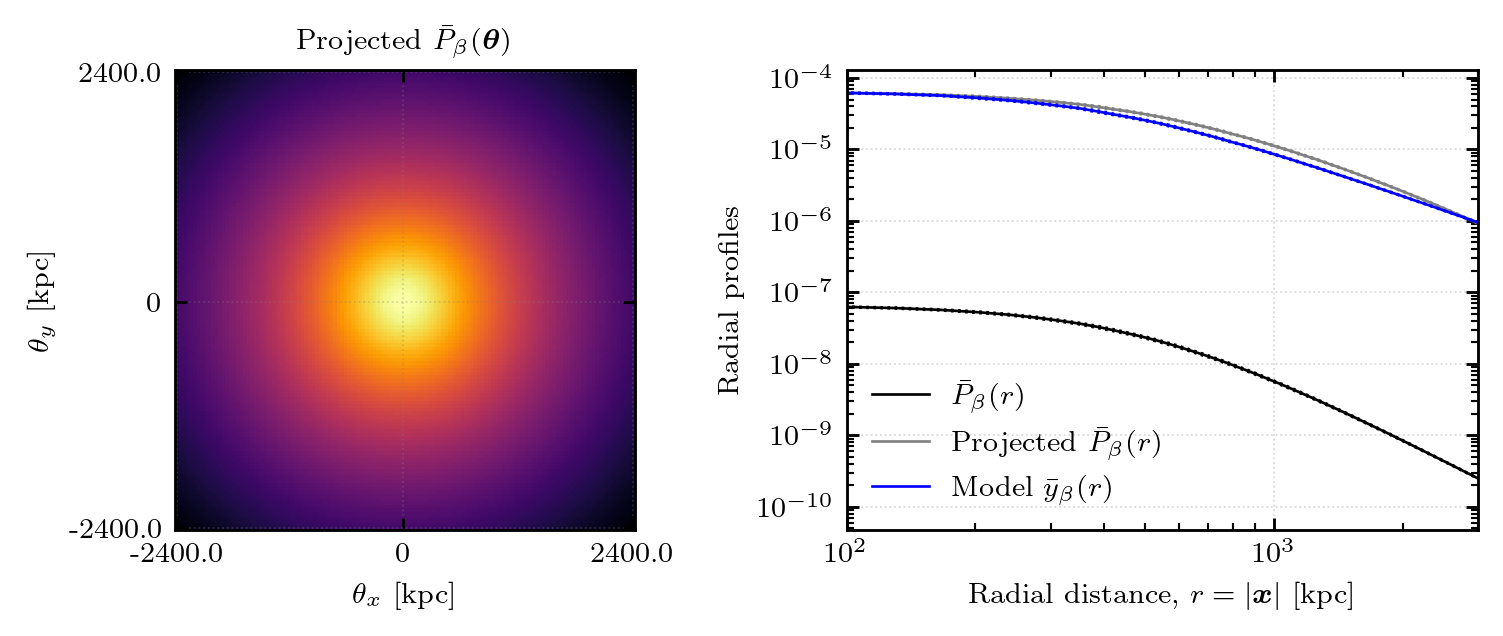

In [177]:
## Plot mean beta profile
fig, ax = plt.subplots(1,2,figsize=(7., 7./3.), dpi=256)
ax[0].imshow(Pm_proj, origin='lower', interpolation='none', cmap='inferno', norm=mpl.colors.LogNorm())

ax[1].plot(_r, Pm_avg, linestyle='-', color='black', linewidth=0.75, label=r'$\bar{P}_{\beta}(r)$')
ax[1].plot(_r, Pm_avg-Pm_std, linestyle=':', color='black', linewidth=0.75)
ax[1].plot(_r, Pm_avg+Pm_std, linestyle=':', color='black', linewidth=0.75)

ax[1].plot(_rp, Pmp_avg, linestyle='-', color='gray', linewidth=0.75, label=r'Projected $\bar{P}_{\beta}(r)$')
ax[1].plot(_rp, Pmp_avg-Pmp_std, linestyle=':', color='gray', linewidth=0.75)
ax[1].plot(_rp, Pmp_avg+Pmp_std, linestyle=':', color='gray', linewidth=0.75)

ax[1].plot(_r2, ym2_avg, linestyle='-', color='blue', linewidth=0.75, label=r'Model $\bar{y}_{\beta}(r)$')
ax[1].plot(_r2, ym2_avg-ym2_std, linestyle=':', color='blue', linewidth=0.75)
ax[1].plot(_r2, ym2_avg+ym2_std, linestyle=':', color='blue', linewidth=0.75)

ax[1].legend(fancybox=False, frameon=False)

plotting.pretty_axes(ax[0])
plotting.pretty_axes(ax[1])
ax[0].set_yticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_ylabel(r'$\theta_y$ [kpc]')
ax[0].set_xticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_xlabel(r'$\theta_x$ [kpc]')
ax[0].set_title(r'Projected $\bar{P}_{\beta}(\boldsymbol{\theta})$', fontsize=8.)
ax[1].set_xlabel(r'Radial distance, $r = |\boldsymbol{x}|$ [kpc]')
ax[1].set_ylabel(r'Radial profiles')
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_xlim((100, 3000))

In [178]:
## Make model for fluctuations
# Effective injection scale and effective dissipation scale
ki, kd = (5.*dk, 500.*dk)
# What we want the value to be at the peak of the amplitude spectrum (approximately)
p = 0.2
# Modal/angle-averaged spectrum powerlaw
alpha = 11./3.
## Generate fluctuations
Pf = fbm.create_fbm(grid_dims, phys_dims, (-alpha,), gfunc='pow_exp', func_kwargs={'breaks': (ki, kd)}, A=p**2)
Pf = Pm*Pf
Pf_proj = np.nansum(Pf, axis=2)*dx

/home/m/Documents/my_libs/Kea/Kea/utils/funcs.py:114: RuntimeWarning: divide by zero encountered in power
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)
/home/m/Documents/my_libs/Kea/Kea/utils/funcs.py:114: RuntimeWarning: divide by zero encountered in divide
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)
/home/m/Documents/my_libs/Kea/Kea/utils/funcs.py:114: RuntimeWarning: invalid value encountered in multiply
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)


-3.081086594257347e-08 3.1915906356968446e-08 -6.476260526822931e-12 6.591471924409913e-10


Text(0.5, 1.0, 'Projected $\\delta P(\\boldsymbol{\\theta})$')

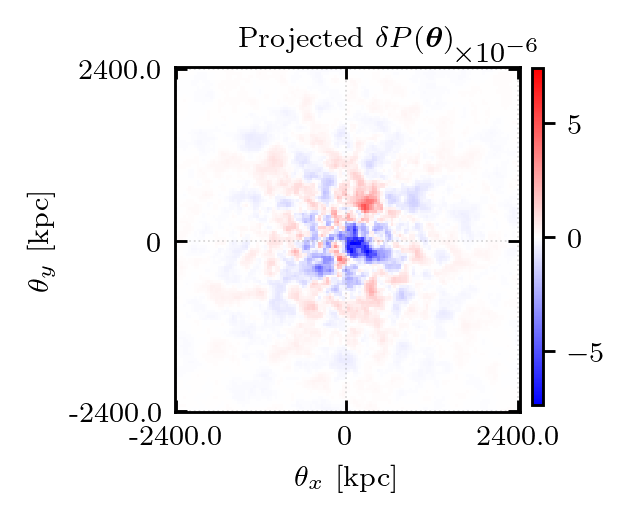

In [179]:
fig, ax = plt.subplots(1, 1, figsize=(1.75, 1.75), dpi=256)
print(np.min(Pf), np.max(Pf), np.mean(Pf), np.std(Pf))
cmin, cmax = plotting.get_minmax(Pf_proj)
im = ax.imshow(Pf_proj, interpolation='none', origin='lower', cmap='bwr', vmin=cmin, vmax=cmax)
plotting.pretty_axes(ax)
ax.set_yticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax.set_ylabel(r'$\theta_y$ [kpc]')
ax.set_xticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax.set_xlabel(r'$\theta_x$ [kpc]')
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.925, 0.125, 0.025, 0.7525])
fig.colorbar(im, cax=cbar_ax, orientation='vertical')
ax.set_title(r'Projected $\delta P(\boldsymbol{\theta})$', fontsize=8.)

In [180]:
## Make observed field
Pobs = Pm + Pf
_r, Pobs_avg, _ = statistics_base.bin_data(r, Pobs, np.nanmean)
_r, Pobs_std, _ = statistics_base.bin_data(r, Pobs, np.nanstd)
Pobs_proj = np.nanmean(Pobs, axis=2)

-1.1900843971670354 1.1063913686644642


(100, 2000)

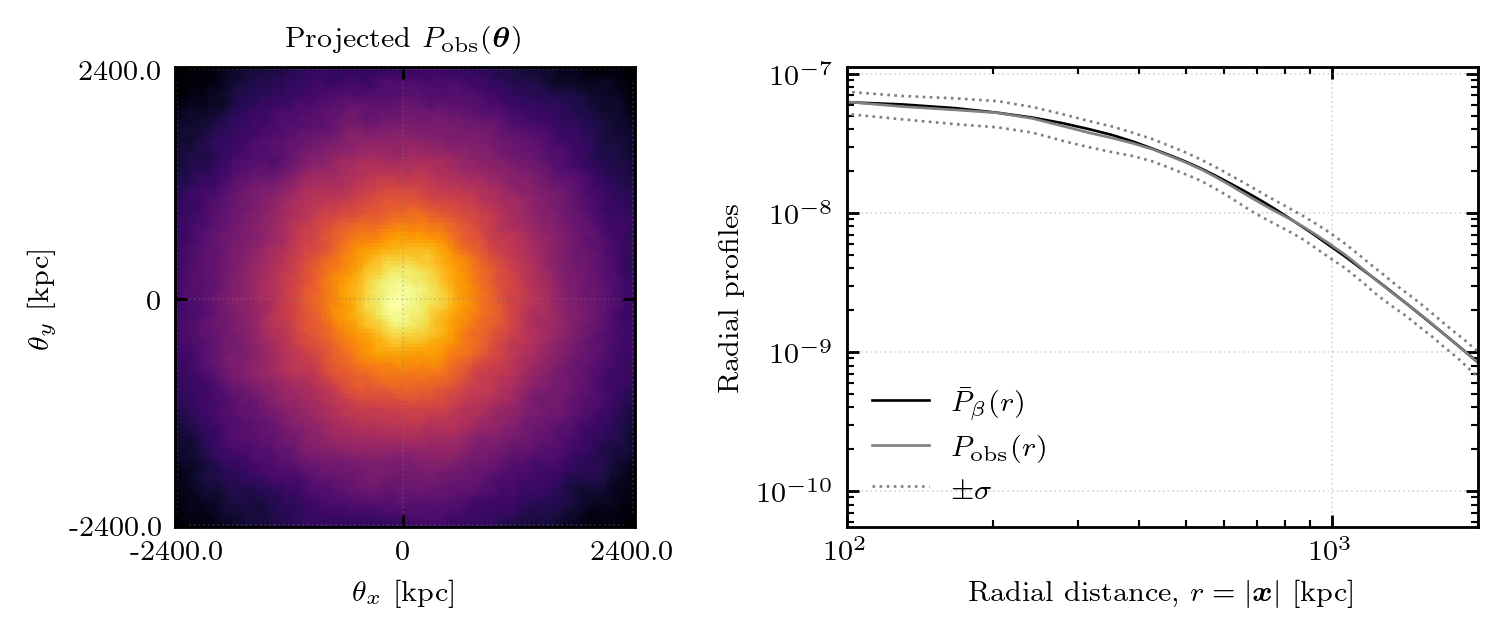

In [181]:
## Plot mean profile
fig, ax = plt.subplots(1,2,figsize=(7., 7./3.), dpi=256)
print(np.min(Pf/Pm), np.max(Pf/Pm))
cmin, cmax = plotting.get_minmax(Pobs_proj)
ax[0].imshow(Pobs_proj, origin='lower', interpolation='none', cmap='inferno', norm=mpl.colors.LogNorm())
ax[1].plot(_r, Pm_avg, linestyle='-', color='black', linewidth=0.75, label=r'$\bar{P}_{\beta}(r)$')
ax[1].plot(_r, Pobs_avg, linestyle='-', color='gray', linewidth=0.75, label=r'$P_{\mathrm{obs}}(r)$')
ax[1].plot(_r, Pobs_avg-Pobs_std, linestyle=':', color='gray', linewidth=0.75, label=r'$\pm \sigma$')
ax[1].plot(_r, Pobs_avg+Pobs_std, linestyle=':', color='gray', linewidth=0.75)
ax[1].legend(fancybox=False, frameon=False)
plotting.pretty_axes(ax[0])
plotting.pretty_axes(ax[1])
ax[0].set_yticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_ylabel(r'$\theta_y$ [kpc]')
ax[0].set_xticks([0, N//2-1, N-1], [-L/2., 0, L/2.])
ax[0].set_xlabel(r'$\theta_x$ [kpc]')
ax[0].set_title(r'Projected $P_{\mathrm{obs}}(\boldsymbol{\theta})$', fontsize=8.)
ax[1].set_xlabel(r'Radial distance, $r = |\boldsymbol{x}|$ [kpc]')
ax[1].set_ylabel(r'Radial profiles')
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_xlim((100, 2000))

In [182]:
## Calculate amplitude spectrum
from Kea.statistics.spectra import per_spectra
# Modal spectrum 
kvec, fekm = per_spectra.modal_spectrum(Pf/Pm, phys_dims=phys_dims)
# Angle-integrated spectrum
ko, feko, wo = spectra_base.spectrum_integrate(kvec, fekm*(dk/twopi)**D, lenn=phys_dims)
# Amplitude spectrum
feka = np.sqrt(ko*feko)

Text(0.5, 0, 'Wavenumber, $k$ [kpc$^{-1}$]')

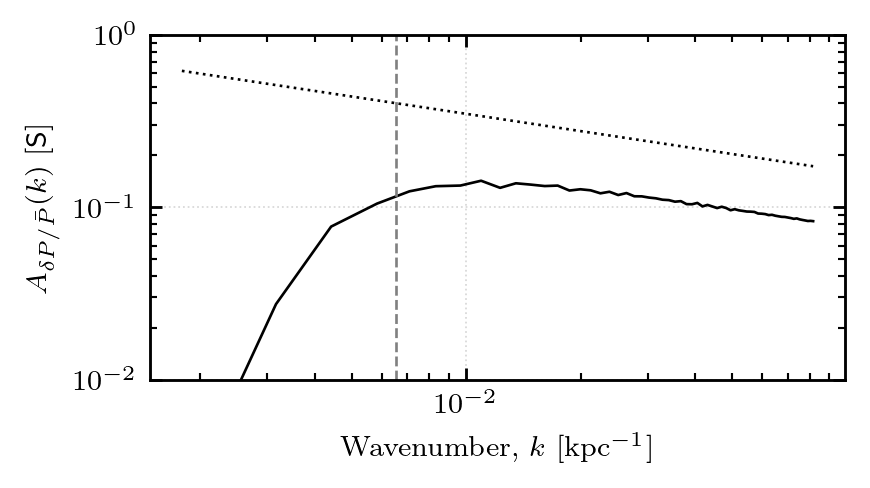

In [183]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)
ax.plot(ko, feka, linestyle='-', linewidth=0.75, color='black')
ax.axvline(ki, linestyle='--', color='gray', linewidth=0.75)
if kd <= np.max(ko):
    ax.axvline(kd, linestyle='--', color='gray', linewidth=0.75)
ax.plot(ko, 7.5e-2*ko**(-1./3.), linestyle=':', color='black', linewidth=0.75)
plotting.pretty_axes(ax)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim((1e-2, 1e0))
# The amplitude spectrum is in units of the signal [`S`]. Since delta-P/bar-P is dimensionless, then so is the amplitude spectrum.
ax.set_ylabel(r'$A_{\delta P/\bar{P}}(k)$ [\textsf{S}]')
ax.set_xlabel(r'Wavenumber, $k$ [kpc$^{-1}$]')